<a href="https://colab.research.google.com/github/UnegbuSogidechukwu/HackUMBC2026_Sewage_prediction/blob/main/Another_copy_of_Untitled0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **INTRODCUTION AND INSTALLATION OF ALL THAT WOULD BE USED**


In [ ]:
!pip install prophet streamlit pyngrok -q

import pandas as pd
import numpy as np
from prophet import Prophet
import plotly.graph_objects as go

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 77.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 97.9 MB/s eta 0:00:00


In [ ]:
# load csv
Pre_2023 = pd.read_csv('/content/Reported_Sewer_Overflows_20260926.csv')
Post_2023 = pd.read_csv('/content/Reported_Sewer_Overflows_(New_for_2023)_20260926.csv')



In [ ]:
# view columns and such
Pre_2023.head()
Pre_2023.info()
Pre_2023.describe()

Post_2023.head()
Post_2023.info()
Post_2023.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27479 entries, 0 to 27478
Data columns (total 22 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Overflow Type                    27478 non-null  object 
 1   Municipality/Facility            27479 non-null  object 
 2   NPDES #                          10824 non-null  object 
 3   Date Discovered                  27479 non-null  object 
 4   Time Discovered                  21281 non-null  object 
 5   Duration - Days                  20548 non-null  object 
 6   Duration - Hours                 20617 non-null  object 
 7   Duration - Minutes               20595 non-null  object 
 8   Location                         27473 non-null  object 
 9   Zip Code                         26040 non-null  float64
 10  Collection-System                23539 non-null  object 
 11  Quantity in Gallons (Estimated)  27420 non-null  object 
 12  Net in Gallons (Es

,DURATION_DAY,DURATION_HOUR,DURATION_MINUTE
count,3425.000000,3425.000000,3425.000000
mean,1.176058,4.235036,18.357664
std,9.691184,5.636574,17.750599
min,0.000000,0.000000,-56.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,2.000000,15.000000
75%,0.000000,6.000000,30.000000
max,222.000000,23.000000,59.000000


DROP COLUMNS DEEMED NOT USEFUL

In [ ]:
columns_to_drop_pre_2023 = [
    'NPDES #',
    'Notes',
    'Penalty Comments',
    'Penalty Collected',
    'Receiving waters'
]

columns_to_drop_post_2023 = [
    'NPDES_NO',
    'ID',
    'PENALTY_ID',
    'OWNER_NAME',
    'OVERFLOW_ADDRESS',
    'RECEIVING_WATER'
]

Pre_2023 = Pre_2023.drop(columns=columns_to_drop_pre_2023, errors='ignore')
Post_2023 = Post_2023.drop(columns=columns_to_drop_post_2023, errors='ignore')

print("Columns after dropping for Pre_2023:")
print(Pre_2023.columns.tolist())
print("\nColumns after dropping for Post_2023:")
print(Post_2023.columns.tolist())

Columns after dropping for Pre_2023:
['Overflow Type', 'Municipality/Facility', 'Date Discovered', 'Time Discovered', 'Duration - Days', 'Duration - Hours', 'Duration - Minutes', 'Location', 'Zip Code', 'Collection-System', 'Quantity in Gallons (Estimated)', 'Net in Gallons (Estimated)', 'Cause', 'Watershed', 'County', 'Latitude', 'Longitude']

Columns after dropping for Post_2023:
['OVERFLOW_TYPE', 'FACILITY/COLLECTION_SYSTEM', 'START_DATE', 'START_TIME', 'DURATION_DAY', 'DURATION_HOUR', 'DURATION_MINUTE', 'ZIP', 'DISCHARGE_VOLUME', 'OVERFLOW_CAUSE', 'COUNTY', 'OVERFLOW_LATITUDE', 'OVERFLOW_LONGITUDE']


In [ ]:
# Rename Pre-2023 columns
pre = Pre_2023.rename(columns={
    "Overflow Type": "overflow_type",
    "Municipality/Facility": "facility",
    "Date Discovered": "date",
    "Time Discovered": "time",
    "Duration - Days": "duration_day",
    "Duration - Hours": "duration_hour",
    "Duration - Minutes": "duration_minute",
    "Location": "location",
    "Zip Code": "zip",
    "Collection-System": "collection_system",
    "Quantity in Gallons (Estimated)": "discharge_volume",
    "Net in Gallons (Estimated)": "net_volume",
    "Cause": "cause",
    "Watershed": "watershed",
    "County": "county",
    "Latitude": "latitude",
    "Longitude": "longitude"
})

# Rename Post-2023 columns
post = Post_2023.rename(columns={
    "OVERFLOW_TYPE": "overflow_type",
    "FACILITY/COLLECTION_SYSTEM": "facility",
    "START_DATE": "date",
    "START_TIME": "time",
    "DURATION_DAY": "duration_day",
    "DURATION_HOUR": "duration_hour",
    "DURATION_MINUTE": "duration_minute",
    "ZIP": "zip",
    "DISCHARGE_VOLUME": "discharge_volume",
    "OVERFLOW_CAUSE": "cause",
    "COUNTY": "county",
    "OVERFLOW_LATITUDE": "latitude",
    "OVERFLOW_LONGITUDE": "longitude"
})

In [ ]:
columns = [
    "overflow_type",
    "facility",
    "date",
    "time",
    "duration_day",
    "duration_hour",
    "duration_minute",
    "zip",
    "discharge_volume",
    "cause",
    "county",
    "latitude",
    "longitude"
]

pre = pre[columns]
post = post[columns]

df = pd.concat([pre, post], ignore_index=True)

In [ ]:
# Convert duration columns to numeric, coercing errors and filling NaN with 0
df['duration_minute'] = pd.to_numeric(df['duration_minute'], errors='coerce').fillna(0)
df['duration_hour'] = pd.to_numeric(df['duration_hour'], errors='coerce').fillna(0)
df['duration_day'] = pd.to_numeric(df['duration_day'], errors='coerce').fillna(0)

# Now calculate and print the minimums
print(f"Min duration_minute: {df['duration_minute'].min()}")
print(f"Min duration_hour: {df['duration_hour'].min()}")
print(f"Min duration_day: {df['duration_day'].min()}")

# drop all rows where duration is less than 0 (after converting to numeric)
df = df[df['duration_minute'] >= 0]
df = df[df['duration_hour'] >= 0]
df = df[df['duration_day'] >= 0]

Min duration_minute: -56.0
Min duration_hour: 0.0
Min duration_day: 0.0


In [ ]:
# Check if individual duration columns exist before processing
if 'duration_day' in df.columns and 'duration_hour' in df.columns and 'duration_minute' in df.columns:
    df['duration_day'] = pd.to_numeric(df['duration_day'], errors='coerce').fillna(0)
    df['duration_hour'] = pd.to_numeric(df['duration_hour'], errors='coerce').fillna(0)
    df['duration_minute'] = pd.to_numeric(df['duration_minute'], errors='coerce').fillna(0)

    # Calculate total duration in hours
    df['duration'] = (df['duration_day'] * 24) + df['duration_hour'] + (df['duration_minute'] / 60)

    # Drop the original duration columns
    df = df.drop(columns=['duration_day', 'duration_hour', 'duration_minute'])
else:
    print("Individual duration columns (duration_day, duration_hour, duration_minute) not found. Assuming 'duration' column is already created or not intended to be created from these.")


# df.info()
# print all null or NaN

rows_with_nan = df[df.isna().any(axis=1)]
print("Rows with NaN values:")
print(rows_with_nan)

# show number for longitude and latitude columns with NaN
# Corrected column names to lowercase 'latitude' and 'longitude'
print("\nNumber of NaN values in latitude and longitude columns:")
print(df[["latitude", "longitude"]].isna().sum())

# drop latitude and longitude columns
df = df.drop(columns=['latitude', 'longitude'])

# drop na
df = df.dropna()

# change date to date time series
df['date'] = pd.to_datetime(df['date'])
# drop all duration less than 0
df = df[df['duration'] > 0]

df.info()

Rows with NaN values:
      overflow_type                                           facility  \
0               SSO                                        Orbital ATK   
2               SSO                                 Holcim, U.S., Inc.   
3               SSO                                 Holcim, U.S., Inc.   
4            BYPASS                                Navy, Department of   
5               SSO                              Washington County DPW   
...             ...                                                ...   
30920           SSO  Back River WWTP Collection System - Baltimore ...   
30923           CSO  John J. DiFonzo (Cumberland) WRF & Collection ...   
30925           SSO  Kent Narrows/Stevensville/Grasonville WWTP Col...   
30928           SSO                           Private System (PG. Co.)   
30934           SSO  Back River WWTP Collection System - Baltimore ...   

             date         time      zip discharge_volume  \
0      07/26/2017          Na

In [ ]:
# Check what's actually in these two columns before assuming format
print(df['county'].unique())
print(df['discharge_volume'].head(20).tolist())

['Washington' 'Allegany' 'Worcester' 'Caroline' 'Calvert' 'Cecil'
 "Queen Anne's" 'Charles' 'Wicomico' 'Somerset' 'Frederick' 'Anne Arundel'
 'Montgomery' 'Garrett' 'Harford' 'Carroll' 'BALTIMORE COUNTY'
 'Baltimore City' 'Alegany' 'Allegamy' "Prince George's" 'Talbot' 'Howard'
 'ALLEGANY' 'Baltimore County' "St. Mary's" 'Dorchester' 'Kent' 'Virginia'
 'Loudoun County, VA' 'CALVERT' 'Harford County' 'District of Columbia'
 'Cecil County' 'AnneArundel' 'Baltimore CIty' 'Batimore City'
 'Washington DC' 'Baltimore']
['300', '300', '500', '2,000', '988,082', '56,000', '50,000', '0', '0', '0', '0', '576,000', '200,000', '329,000', '66,000', '5,000', '262,000', '86,100', '100', '1,000,000']


In [ ]:
# Clean discharge_volume: strip commas/units, coerce non-numeric to NaN
df['discharge_volume_clean'] = (
    df['discharge_volume']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.extract(r'([\d.]+)')[0]  # pulls out just the numeric part
)
df['discharge_volume_clean'] = pd.to_numeric(df['discharge_volume_clean'], errors='coerce')

print(f"Rows before cleaning: {len(df)}")
print(f"Rows with valid volume: {df['discharge_volume_clean'].notna().sum()}")
df = df.dropna(subset=['discharge_volume_clean'])

Rows before cleaning: 21530
Rows with valid volume: 21530


In [ ]:
weekly = (
    df
    .set_index('date')
    .resample('W')['discharge_volume_clean']
    .sum()
    .reset_index()
)
weekly.columns = ['ds', 'y']

fig = go.Figure(go.Scatter(x=weekly['ds'], y=weekly['y'], mode='lines'))
fig.update_layout(title='Weekly Sewage Discharge Volume — Baltimore', xaxis_title='Date', yaxis_title='Gallons')
fig.show()

In [ ]:
weekly['y_log'] = np.log1p(weekly['y'])  # log1p handles the zero-values safely

fig = go.Figure(go.Scatter(x=weekly['ds'], y=weekly['y_log'], mode='lines'))
fig.update_layout(title='Log-Transformed Weekly Discharge Volume', xaxis_title='Date', yaxis_title='log(gallons + 1)')
fig.show()

In [ ]:
gap_check = weekly[(weekly['ds'] >= '2014-01-01') & (weekly['ds'] <= '2017-01-01')]
print(gap_check['y'].describe())
print((gap_check['y'] == 0).sum(), "zero-weeks out of", len(gap_check))

count    1.570000e+02
mean     1.920051e+06
std      5.279083e+06
min      9.300000e+01
25%      1.203300e+04
50%      7.406100e+04
75%      7.962400e+05
max      3.705895e+07
Name: y, dtype: float64
0 zero-weeks out of 157


In [ ]:
prophet_df = weekly[['ds', 'y_log']].rename(columns={'y_log': 'y'})
model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model.fit(prophet_df)

future = model.make_future_dataframe(periods=52, freq='W')
forecast = model.predict(future)

# Convert back to actual gallons for display
forecast['yhat_gallons'] = np.expm1(forecast['yhat'])
forecast['yhat_upper_gallons'] = np.expm1(forecast['yhat_upper'])
forecast['yhat_lower_gallons'] = np.expm1(forecast['yhat_lower'])

fig2 = go.Figure()
fig2.add_trace(go.Scatter(x=weekly['ds'], y=weekly['y'], mode='markers', name='Actual', marker=dict(size=3)))
fig2.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_gallons'], mode='lines', name='Forecast'))
fig2.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_upper_gallons'], mode='lines', line=dict(width=0), showlegend=False))
fig2.add_trace(go.Scatter(x=forecast['ds'], y=forecast['yhat_lower_gallons'], mode='lines', line=dict(width=0), fill='tonexty', name='Confidence band'))
fig2.show()

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
df.info()
forecast.info()

# Save the forecast + actuals as CSV
forecast.to_csv('forecast.csv', index=False)
df.to_csv('df.csv', index=False)

# rename date


# Download both to your local machine
from google.colab import files
files.download('df.csv')
files.download('forecast.csv')

<class 'pandas.core.frame.DataFrame'>
Index: 21530 entries, 2 to 30933
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   overflow_type           21530 non-null  object        
 1   facility                21530 non-null  object        
 2   date                    21530 non-null  datetime64[ns]
 3   time                    21530 non-null  object        
 4   zip                     21530 non-null  object        
 5   discharge_volume        21530 non-null  object        
 6   cause                   21530 non-null  object        
 7   county                  21530 non-null  object        
 8   duration                21530 non-null  float64       
 9   discharge_volume_clean  21530 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 1.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1187 entries, 0 to 1186
Data columns (total 19 columns)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

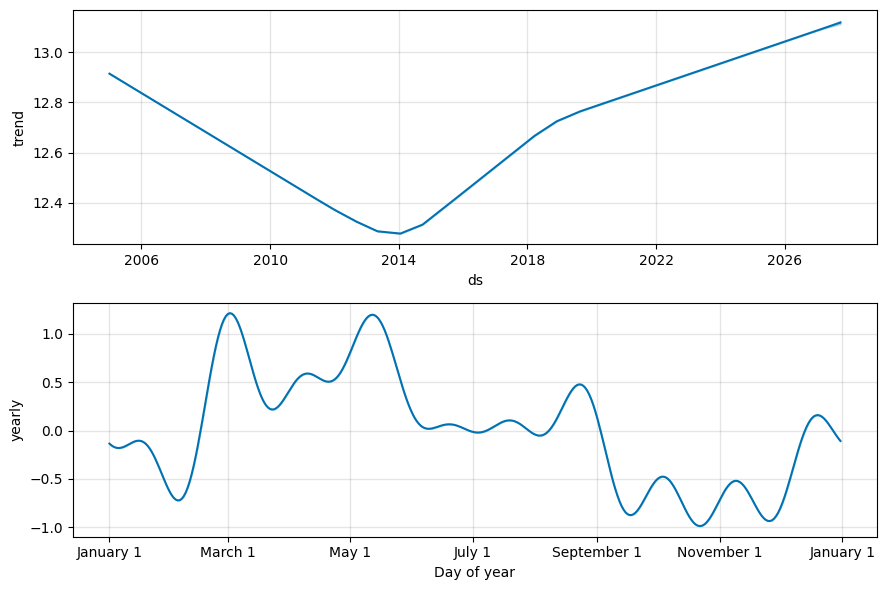

In [ ]:
fig3 = model.plot_components(forecast)

In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics
df_cv = cross_validation(model, initial='3650 days', period='365 days', horizon='180 days')
df_p = performance_metrics(df_cv)
print("Available performance metrics columns:", df_p.columns.tolist())
print(df_p[['horizon', 'rmse']].head())

from prophet import Prophet
from prophet.diagnostics import cross_validation
import pandas as pd
import numpy as np # Import numpy for np.sqrt

# Fit your meta model
m = Prophet()
m.fit(prophet_df) # Changed from m.fit(df) to m.fit(prophet_df)

# Run cross-validation
df_cv = cross_validation(
    m,
    horizon='365 days',   # forecast horizon
    initial='730 days',   # min training data
    period='180 days'    # spacing between cutoffs
    # Removed units='days' as it's not a valid argument
)

# Compute accuracy metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(df_cv['y'], df_cv['yhat'])
rmse = np.sqrt(mean_squared_error(df_cv['y'], df_cv['yhat'])) # Corrected RMSE calculation
r2 = r2_score(df_cv['y'], df_cv['yhat'])

print(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}")

INFO:prophet:Making 12 forecasts with cutoffs between 2015-04-03 00:00:00 and 2026-03-31 00:00:00


  0%|          | 0/12 [00:00<?, ?it/s]

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Available performance metrics columns: ['horizon', 'mse', 'rmse', 'mae', 'mape', 'mdape', 'smape', 'coverage']
  horizon      rmse
0 18 days  2.797024
1 19 days  2.810767
2 20 days  2.860273
3 21 days  2.747860
4 22 days  2.802114


INFO:prophet:Making 39 forecasts with cutoffs between 2007-01-05 00:00:00 and 2025-09-27 00:00:00


  0%|          | 0/39 [00:00<?, ?it/s]

MAE: 2.5441, RMSE: 3.1109, R²: -0.0983


In [ ]:
print(df_p[['horizon', 'rmse', 'mae']].head())

  horizon      rmse       mae
0 18 days  2.797024  2.371885
1 19 days  2.810767  2.405213
2 20 days  2.860273  2.455889
3 21 days  2.747860  2.385922
4 22 days  2.802114  2.460712


In [ ]:
gap_check = df[(df['date'] >= '2014-01-01') & (df['date'] <= '2017-01-01')]
print(f"Rows in this window: {len(gap_check)}")
print(f"Unique facilities reporting: {gap_check['facility'].nunique()}")

Rows in this window: 2311
Unique facilities reporting: 132


POST DATA PREPROCESSING

In [ ]:
prophet_df = weekly[['ds', 'y_log']].rename(columns={'y_log': 'y'})
model = Prophet(yearly_seasonality=True, weekly_seasonality=False)
model.fit(prophet_df)

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


In [ ]:
from prophet.diagnostics import cross_validation, performance_metrics

df_cv = cross_validation(model, initial='3650 days', period='365 days', horizon='180 days')
df_p = performance_metrics(df_cv)
print(df_p[['horizon', 'rmse', 'mae']].head(10))

INFO:prophet:Making 12 forecasts with cutoffs between 2015-04-03 00:00:00 and 2026-03-31 00:00:00


  0%|          | 0/12 [00:00<?, ?it/s]

  horizon      rmse       mae
0 18 days  2.797024  2.371885
1 19 days  2.810767  2.405213
2 20 days  2.860273  2.455889
3 21 days  2.747860  2.385922
4 22 days  2.802114  2.460712
5 23 days  2.755363  2.424271
6 24 days  2.693798  2.382077
7 25 days  2.591137  2.259496
8 26 days  2.515483  2.160056
9 27 days  2.428488  2.069935


In [ ]:
import numpy as np

future = model.make_future_dataframe(periods=104, freq='W')  # 2 years out, since your data spans ~20 years
forecast = model.predict(future)

# Convert back from log space to real gallons
forecast['yhat_gallons'] = np.expm1(forecast['yhat'])
forecast['yhat_upper_gallons'] = np.expm1(forecast['yhat_upper'])
forecast['yhat_lower_gallons'] = np.expm1(forecast['yhat_lower'])

# Also carry the actual historical values into the same dataframe for easy plotting later
forecast = forecast.merge(weekly[['ds', 'y']], on='ds', how='left')
forecast.rename(columns={'y': 'actual_gallons'}, inplace=True)

In [ ]:
# remove all entries in forecast for before september 26 2026
forecast = forecast[forecast['ds'] >= '2026-09-26']

# check info for forecast after change
forecast.info()



<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 1134 to 1238
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ds                          105 non-null    datetime64[ns]
 1   trend                       105 non-null    float64       
 2   yhat_lower                  105 non-null    float64       
 3   yhat_upper                  105 non-null    float64       
 4   trend_lower                 105 non-null    float64       
 5   trend_upper                 105 non-null    float64       
 6   additive_terms              105 non-null    float64       
 7   additive_terms_lower        105 non-null    float64       
 8   additive_terms_upper        105 non-null    float64       
 9   yearly                      105 non-null    float64       
 10  yearly_lower                105 non-null    float64       
 11  yearly_upper                105 non-null    float64       


In [ ]:
import pickle

# Save the fitted model
with open('prophet_model.pkl', 'wb') as f:
    pickle.dump(model, f)

df.info()
forecast.info()

# Save the forecast + actuals as CSV
forecast.to_csv('forecast.csv', index=False)
df.to_csv('df.csv', index=False)

# rename date


# Download both to your local machine
from google.colab import files
files.download('df.csv')
files.download('prophet_model.pkl')
files.download('forecast.csv')


<class 'pandas.core.frame.DataFrame'>
Index: 21530 entries, 2 to 30933
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   overflow_type           21530 non-null  object        
 1   facility                21530 non-null  object        
 2   date                    21530 non-null  datetime64[ns]
 3   time                    21530 non-null  object        
 4   zip                     21530 non-null  object        
 5   discharge_volume        21530 non-null  object        
 6   cause                   21530 non-null  object        
 7   county                  21530 non-null  object        
 8   duration                21530 non-null  float64       
 9   discharge_volume_clean  21530 non-null  float64       
dtypes: datetime64[ns](1), float64(2), object(7)
memory usage: 1.8+ MB
<class 'pandas.core.frame.DataFrame'>
Index: 105 entries, 1134 to 1238
Data columns (total 20 columns):
 

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>